In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests
from datetime import datetime, timedelta

import pandas as pd
import requests_cache
from retry_requests import retry

import pvlib

import pickle

In [2]:
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [3]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -29,
	"longitude": 24,
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "snowfall", "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "wind_speed_10m", "wind_speed_80m", "wind_direction_10m", "wind_direction_80m", "shortwave_radiation_instant", "wind_gusts_10m"],
	"current": ["precipitation", "snowfall", "cloud_cover", "wind_speed_10m", "wind_direction_10m", "temperature_2m", "relative_humidity_2m"],
	"timezone": "auto",
}
responses = openmeteo.weather_api(url, params = params)

In [4]:
response = responses[0]
current = response.Current()
hourly = response.Hourly()

In [5]:
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(3).ValuesAsNumpy()
hourly_cloud_cover = hourly.Variables(4).ValuesAsNumpy()
hourly_cloud_cover_low = hourly.Variables(5).ValuesAsNumpy()
hourly_cloud_cover_mid = hourly.Variables(6).ValuesAsNumpy()
hourly_cloud_cover_high = hourly.Variables(7).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(8).ValuesAsNumpy()
hourly_wind_speed_80m = hourly.Variables(9).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(10).ValuesAsNumpy()
hourly_wind_direction_80m = hourly.Variables(11).ValuesAsNumpy()
hourly_shortwave_radiation_instant = hourly.Variables(12).ValuesAsNumpy()
hourly_wind_gusts_10m = hourly.Variables(13).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
    ).tz_convert(response.Timezone().decode('ascii'))
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["snowfall"] = hourly_snowfall
hourly_data["cloud_cover"] = hourly_cloud_cover
hourly_data["cloud_cover_high"] = hourly_cloud_cover_high
hourly_data["cloud_cover_mid"] = hourly_cloud_cover_mid
hourly_data["cloud_cover_low"] = hourly_cloud_cover_low
hourly_data["shortwave_radiation_instant"] = hourly_shortwave_radiation_instant
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_speed_80m"] = hourly_wind_speed_80m
hourly_data["wind_direction_80m"] = hourly_wind_direction_80m
hourly_data["wind_gusts_10m"] = hourly_wind_gusts_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Hourly data
                          date  temperature_2m  relative_humidity_2m  \
0   2026-05-09 02:00:00+02:00            5.85             90.090645   
1   2026-05-09 03:00:00+02:00            5.45             90.694618   
2   2026-05-09 04:00:00+02:00            4.95             91.944069   
3   2026-05-09 05:00:00+02:00            4.40             93.545631   
4   2026-05-09 06:00:00+02:00            3.95             94.854706   
..                        ...             ...                   ...   
163 2026-05-15 21:00:00+02:00           14.65             75.420555   
164 2026-05-15 22:00:00+02:00           13.55             79.650406   
165 2026-05-15 23:00:00+02:00           12.75             82.804253   
166 2026-05-16 00:00:00+02:00           12.05             85.544151   
167 2026-05-16 01:00:00+02:00           11.45             87.812241   

     precipitation  snowfall  cloud_cover  cloud_cover_high  cloud_cover_mid  \
0              0.0       0.0          0.0            

In [6]:
now = datetime.now().replace(microsecond=0, second=0, minute=0)
end = pd.Timestamp(now + timedelta(days=7), tz='UTC')
now = pd.Timestamp(now, tz='UTC')

In [7]:
data = hourly_dataframe[hourly_dataframe["date"] >= now]
data = data[data["date"] <= end]

In [8]:
az = pvlib.solarposition.get_solarposition(data["date"], params["latitude"], params["longitude"])#.drop(["apparent_zenith", "apparent_elevation", "equation_of_time", "elevation"], axis = 1)

In [9]:
data["angle_of_incidence"] = 0
data["zenith"] = np.array(az['zenith'])
data["azimuth"] = np.array(az["azimuth"])
data["angle_of_incidence"] = pvlib.irradiance.aoi(abs(params["latitude"]), 0, data["zenith"],  data["azimuth"])
if params["latitude"] < 0:
   data["azimuth"] = (np.array(az["azimuth"]) + 180) % 360
time = np.array(data["date"])
data = data.drop("date", axis=1)

In [10]:
nkeys = pd.read_csv("normalization_keys.csv")

In [11]:
ykey = nkeys["generated_power_kw"]
nkeys = nkeys.drop("generated_power_kw", axis = 1)

In [12]:
def normalize(df, nkeys):
    df_new = df.copy()
    for key in df_new.keys():
        x = df[key]
        a = nkeys[key][0]
        b = nkeys[key][1]
        df_new[key] = (x-a)/(b-a)
    return df_new

def denormalize_array(arr, normalization_key):
    a = normalization_key[0]
    b = normalization_key[1]
    return (b-a)*arr+a

def denormalize(df, normalization_keys, column = None):
    df_new = df.copy()
    if column:
        df_new = denormalize_array(df_new, normalization_keys[column])
    else:
        for key in df_new.keys():
            df_new[key] = denormalize_array(df[key], normalization_keys[key])
    return df_new

In [13]:
normalized_data = normalize(data, nkeys)

In [14]:
normalized_data.keys()

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation', 'snowfall',
       'cloud_cover', 'cloud_cover_high', 'cloud_cover_mid', 'cloud_cover_low',
       'shortwave_radiation_instant', 'wind_speed_10m', 'wind_direction_10m',
       'wind_speed_80m', 'wind_direction_80m', 'wind_gusts_10m',
       'angle_of_incidence', 'zenith', 'azimuth'],
      dtype='str')

In [15]:
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

In [16]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",75
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [17]:
prediction = model.predict(normalized_data)

In [18]:
result = denormalize_array(prediction, ykey)

In [23]:
ind = np.where(time <= pd.Timestamp(now + timedelta(hours=12)))
ind

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]),)

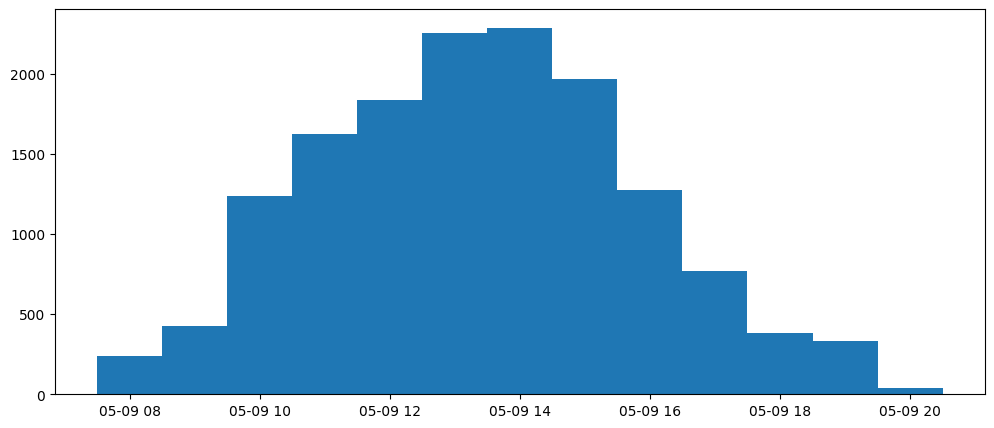

In [24]:
fig = plt.figure(figsize=(12,5))
plt.bar(time[ind], result[ind], width = timedelta(hours=1))
plt.show()